h/J=0.000  <Z>=+1.0000  <X>=-0.0000  <ZiZj>_avg=+1.0000  <ZiZj>_nn=+1.0000
h/J=0.051  <Z>=+0.9997  <X>=+0.0256  <ZiZj>_avg=+0.9993  <ZiZj>_nn=+0.9993
h/J=0.103  <Z>=+0.9987  <X>=+0.0513  <ZiZj>_avg=+0.9974  <ZiZj>_nn=+0.9974
h/J=0.154  <Z>=+0.9970  <X>=+0.0771  <ZiZj>_avg=+0.9940  <ZiZj>_nn=+0.9941
h/J=0.205  <Z>=+0.9946  <X>=+0.1031  <ZiZj>_avg=+0.9893  <ZiZj>_nn=+0.9894
h/J=0.256  <Z>=+0.9915  <X>=+0.1292  <ZiZj>_avg=+0.9832  <ZiZj>_nn=+0.9834
h/J=0.308  <Z>=+0.9877  <X>=+0.1557  <ZiZj>_avg=+0.9756  <ZiZj>_nn=+0.9759
h/J=0.359  <Z>=+0.9829  <X>=+0.1824  <ZiZj>_avg=+0.9664  <ZiZj>_nn=+0.9670
h/J=0.410  <Z>=+0.9771  <X>=+0.2096  <ZiZj>_avg=+0.9555  <ZiZj>_nn=+0.9565
h/J=0.462  <Z>=+0.9693  <X>=+0.2374  <ZiZj>_avg=+0.9427  <ZiZj>_nn=+0.9445
h/J=0.513  <Z>=+0.9563  <X>=+0.2658  <ZiZj>_avg=+0.9278  <ZiZj>_nn=+0.9306
h/J=0.564  <Z>=+0.9267  <X>=+0.2954  <ZiZj>_avg=+0.9104  <ZiZj>_nn=+0.9147
h/J=0.615  <Z>=+0.8520  <X>=+0.3269  <ZiZj>_avg=+0.8896  <ZiZj>_nn=+0.8962
h/J=0.667  <Z>=+0.7006  <

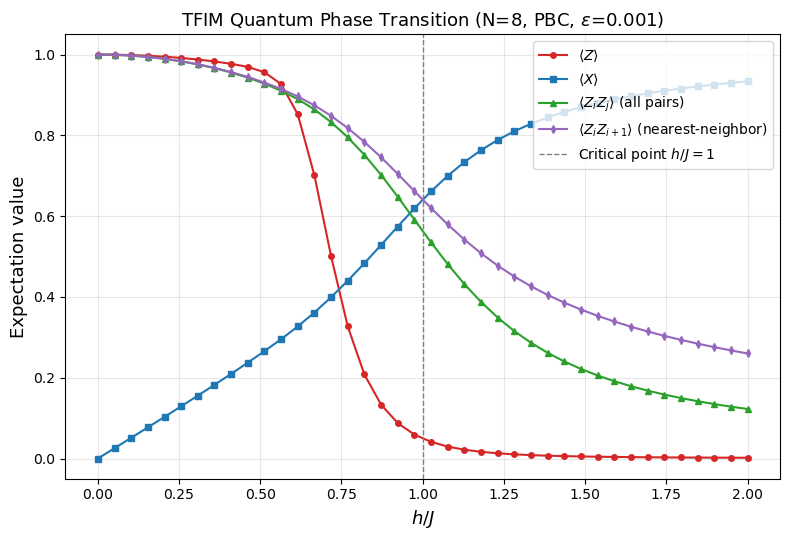

In [8]:
import numpy as np
from scipy.sparse import kron, identity, csr_matrix
from scipy.sparse.linalg import eigsh

X = csr_matrix([[0, 1], [1, 0]])
Z = csr_matrix([[1, 0], [0, -1]])
I = identity(2, format='csr')

def op_on_site(op, site, N):
    ops = [I] * N
    ops[site] = op
    result = ops[0]
    for o in ops[1:]:
        result = kron(result, o, format='csr')
    return result

def build_H(N, J, h, eps=0.0, pbc=True):
    H = csr_matrix((2**N, 2**N))
    bonds = N if pbc else N - 1
    for i in range(bonds):
        j = (i + 1) % N
        H -= J * (op_on_site(Z, i, N) @ op_on_site(Z, j, N))
    for i in range(N):
        H -= h * op_on_site(X, i, N)
        H -= eps * op_on_site(Z, i, N)   # symmetry-breaking field, para poder observar el cambio de fase
    return H

def ground_state(H):
    vals, vecs = eigsh(H, k=1, which='SA')
    return vecs[:, 0]

def expectation(psi, op):
    return (psi.conj() @ (op @ psi)).real

def mean_Z(psi, N):
    return sum(expectation(psi, op_on_site(Z, i, N)) for i in range(N)) / N

def mean_X(psi, N):
    return sum(expectation(psi, op_on_site(X, i, N)) for i in range(N)) / N

def mean_ZZ(psi, N, pbc=True):
    """Media de <Z_i Z_j> sobre todas las posibles parejas i, j."""
    total = 0.0
    count = 0
    for i in range(N):
        for j in range(i + 1, N):
            ZiZj = op_on_site(Z, i, N) @ op_on_site(Z, j, N)
            total += expectation(psi, ZiZj)
            count += 1
    return total / count

def nn_ZZ(psi, N, pbc=True):
    """Media de <Z_i Z_{i+1}> sobre los vecinos mas cercanos."""
    bonds = N if pbc else N - 1
    total = 0.0
    for i in range(bonds):
        j = (i + 1) % N
        ZiZj = op_on_site(Z, i, N) @ op_on_site(Z, j, N)
        total += expectation(psi, ZiZj)
    return total / bonds

N, J = 8, 1.0
eps = 1e-3
ratios = np.linspace(0, 2, 40)

mag_Z, mag_X, corr_ZZ_avg, corr_ZZ_nn = [], [], [], []

for r in ratios:
    h = r * J
    H = build_H(N, J, h, eps=eps, pbc=True)
    psi = ground_state(H)

    mag_Z.append(abs(mean_Z(psi, N)))
    mag_X.append(mean_X(psi, N))
    corr_ZZ_avg.append(mean_ZZ(psi, N, pbc=True))
    corr_ZZ_nn.append(nn_ZZ(psi, N, pbc=True))

for r, z, x, czz_avg, czz_nn in zip(ratios, mag_Z, mag_X, corr_ZZ_avg, corr_ZZ_nn):
    print(f"h/J={r:.3f}  <Z>={z:+.4f}  <X>={x:+.4f}  <ZiZj>_avg={czz_avg:+.4f}  <ZiZj>_nn={czz_nn:+.4f}")

# ---- Plot ----
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(ratios, mag_Z, 'o-', label=r'$\langle Z \rangle$', color='#d62728', markersize=4)
ax.plot(ratios, mag_X, 's-', label=r'$\langle X \rangle$', color='#1f77b4', markersize=4)
#ax.plot(ratios, corr_ZZ_avg, '^-', label=r'$\langle Z_i Z_j \rangle$ (all pairs)', color='#2ca02c', markersize=4)
ax.plot(ratios, corr_ZZ_nn, 'd-', label=r'$\langle Z_i Z_{i+1} \rangle$ (Vecino-cercano)', color='#9467bd', markersize=4)

ax.axvline(1.0, color='gray', linestyle='--', linewidth=1, label=r'Critical point $h/J=1$')

ax.set_xlabel(r'$h/J$', fontsize=13)
ax.set_ylabel('Expectation value', fontsize=13)
ax.set_title(f'TFIM Quantum Phase Transition (N={N}, PBC, $\\epsilon$={eps})', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('TEST_tfim_phase_transition.png', dpi=150)
print("\nPlot saved.")

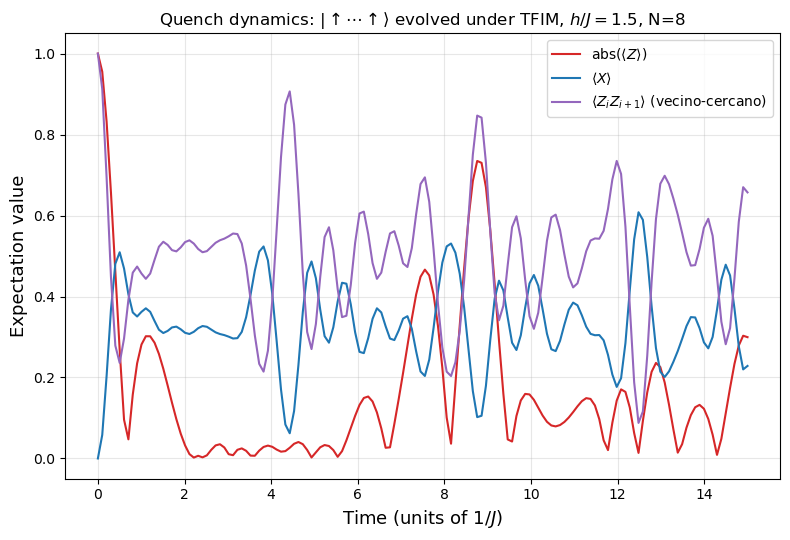

Dynamics plot saved.


In [7]:
# ============================================================
# Time evolution of an initial state under fixed H
# ============================================================
from scipy.sparse.linalg import expm_multiply
 
def initial_state_all_up(N):
    """|000...0> in computational (Z) basis -> all spins +1 along Z."""
    psi0 = np.zeros(2**N, dtype=complex)
    psi0[0] = 1.0
    return psi0
 
def initial_state_all_plus(N):
    """|+++...+> -> all spins +1 along X (product state, eigenstate of X_i)."""
    single = np.array([1, 1], dtype=complex) / np.sqrt(2)
    psi0 = single
    for _ in range(N - 1):
        psi0 = np.kron(psi0, single)
    return psi0
 
def evolve_and_measure(H, psi0, times, N):
    """
    Evolucionar el sistema
    """
    dt_list = np.diff(times)
    psi = psi0.astype(complex).copy()
 
    results = {'Z': [], 'X': [], 'ZZ_avg': [], 'ZZ_nn': []}
 
    def record(psi):
        results['Z'].append(np.abs(mean_Z(psi, N)))
        results['X'].append(mean_X(psi, N))
        results['ZZ_avg'].append(mean_ZZ(psi, N))
        results['ZZ_nn'].append(nn_ZZ(psi, N))
 
    record(psi)  # t = 0
    for dt in dt_list:
        psi = expm_multiply(-1j * H * dt, psi)
        psi /= np.linalg.norm(psi)  # guard against numerical drift
        record(psi)
 
    return results
 
# --- Run a quench: start fully Z-polarized, evolve under TFIM at fixed h/J ---
N_dyn = 8
pbc = True
J = 1.0
h_over_J_quench = 1.5          # <-- change this to explore different phases
h_dyn = h_over_J_quench * J
 
H_dyn = build_H(N_dyn, J, h_dyn, eps=0.0, pbc=pbc)  # eps=0: no need for symmetry-breaking
                                                       # field here, dynamics starts asymmetric
psi0 = initial_state_all_up(N_dyn)
 
t_max = 15.0
n_steps = 150
times = np.linspace(0, t_max, n_steps)
 
dyn = evolve_and_measure(H_dyn, psi0, times, N_dyn)

#save data to an .npz file 
np.savez_compressed(f"Classical_evoultion h={h_dyn}, N={N_dyn}", time=times, Z = dyn['Z'], X = dyn['X'], ZZ_nn = dyn['ZZ_nn'])
 
# --- Plot dynamics ---
fig2, ax2 = plt.subplots(figsize=(8, 5.5))
ax2.plot(times, dyn['Z'], '-', label=r'abs($\langle Z \rangle$)', color='#d62728')
ax2.plot(times, dyn['X'], '-', label=r'$\langle X \rangle$', color='#1f77b4')
#ax2.plot(times, dyn['ZZ_avg'], '-', label=r'$\langle Z_i Z_j \rangle$ (all pairs)', color='#2ca02c')
ax2.plot(times, dyn['ZZ_nn'], '-', label=r'$\langle Z_i Z_{i+1} \rangle$ (vecino-cercano)', color='#9467bd')
 
ax2.set_xlabel('Time (units of $1/J$)', fontsize=13)
ax2.set_ylabel('Expectation value', fontsize=13)
ax2.set_title(f'Quench dynamics: $|{{\\uparrow}}\\cdots\\uparrow\\rangle$ evolved under TFIM, '
              f'$h/J={h_over_J_quench}$, N={N_dyn}', fontsize=12)
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2.savefig(f'tfim_quench_dynamics_h={h_dyn}_N={N_dyn}.png', dpi=150)
plt.show()
print("Dynamics plot saved.")